# Lets see how our initial models do now that we have a lot more data

We already went through this so I will quickly do it below

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler

In [3]:
df = pd.read_csv("data/extra_and_merged_data.csv", index_col="date", parse_dates=True)
df.sort_index(inplace=True)

In [4]:
X = df[["summary", "pct_change", "volume"]]
y = df["target"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [6]:
print(f"Training Range: {X_train.index.min()} to {X_train.index.max()}")
print(f"Testing Range:  {X_test.index.min()} to {X_test.index.max()}")

Training Range: 2003-02-20 00:00:00 to 2018-03-23 00:00:00
Testing Range:  2018-03-26 00:00:00 to 2021-12-30 00:00:00


In [7]:
text_features = "summary"
numerical_features = ["pct_change", "volume"]

In [8]:
preprocessor_sgd = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
            text_features,
        ),
        ("num", StandardScaler(), numerical_features),
    ]
)

preprocessor_lda = ColumnTransformer(
    transformers=[
        # Reduce text to 50 components using SVD (PCA for text)
        (
            "text",
            Pipeline(
                [
                    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                    ("svd", TruncatedSVD(n_components=50)),
                ]
            ),
            text_features,
        ),
        ("num", StandardScaler(), numerical_features),
    ]
)

preprocessor_mnb = ColumnTransformer(
    transformers=[
        (
            "tfidf",
            TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
            text_features,
        ),
        ("scaler", MinMaxScaler(clip=True), numerical_features),
    ]
)

In [9]:
pipeline_sgd = Pipeline([
    ('preprocessor', preprocessor_sgd),
    ('classifier', SGDClassifier(loss='log_loss', penalty='l2', max_iter=1000, random_state=42))
])

pipeline_lda = Pipeline(
    [("preprocessor", preprocessor_lda), ("classifier", LinearDiscriminantAnalysis())]
)

pipeline_mnb = Pipeline([
    ('preprocessor', preprocessor_mnb),
    ('classifier', MultinomialNB(alpha=0.1, fit_prior=False))
])

In [10]:
pipeline_sgd.fit(X_train, y_train)
pipeline_lda.fit(X_train, y_train)
pipeline_mnb.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tfidf', ...), ('scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
y_pred_sgd = pipeline_sgd.predict(X_test)

print("SGD Accuracy:", accuracy_score(y_test, y_pred_sgd))

print(classification_report(y_test, y_pred_sgd))

SGD Accuracy: 0.5458377239199157
              precision    recall  f1-score   support

         0.0       0.47      0.30      0.36       413
         1.0       0.58      0.74      0.65       536

    accuracy                           0.55       949
   macro avg       0.52      0.52      0.50       949
weighted avg       0.53      0.55      0.52       949



In [12]:
y_pred_lda = pipeline_lda.predict(X_test)

print("LDA Accuracy:", accuracy_score(y_test, y_pred_lda))

print(classification_report(y_test, y_pred_lda))

LDA Accuracy: 0.5626975763962065
              precision    recall  f1-score   support

         0.0       0.49      0.17      0.25       413
         1.0       0.57      0.87      0.69       536

    accuracy                           0.56       949
   macro avg       0.53      0.52      0.47       949
weighted avg       0.54      0.56      0.50       949



In [13]:
y_pred_mnb = pipeline_mnb.predict(X_test)

print("MNB Accuracy:", accuracy_score(y_test, y_pred_mnb))

print(classification_report(y_test, y_pred_mnb))

MNB Accuracy: 0.4731296101159115
              precision    recall  f1-score   support

         0.0       0.43      0.62      0.51       413
         1.0       0.55      0.36      0.43       536

    accuracy                           0.47       949
   macro avg       0.49      0.49      0.47       949
weighted avg       0.50      0.47      0.47       949



In [14]:
%%capture
%pip install joblib

In [15]:
# exporting the baseline model to compare after we tune it
import joblib

joblib.dump(pipeline_sgd, "models/sgd_baseline_more_data.pkl")
joblib.dump(pipeline_lda, "models/lda_baseline_more_data.pkl")
joblib.dump(pipeline_mnb, "models/mnb_baseline_more_data.pkl")

['models/mnb_baseline_more_data.pkl']

the models LDA have a pitfall which is causing some underlying issues. The model pretty much always guess up as they have noticed the trend of it rising. It has learned that guessing up is safer. the Naives Bayes came out to worse than random guessing. SGD has same issue of LDA but slightly more balance on its up vs down guesses but it is still heavily guessing up.

Our low F1-score is proving that the model is not actually learning market mechanics it is just guessing based of the trend. We are also drowning out our financial data with our news being a majority. So to combat that we are going to use the news to create a sentiment value and then pass that and the finical data to a model. 

#### Before we continue, lets visualize some more of our results by plotting the ROC curves

The ROC curve is commonly used to evaluate the performance of binary classification models. It plots the true positive rate (sensitivity) against the false positive rate at various threshold settings. The area under the ROC curve (AUC) provides a single metric that summarizes the model's performance across all thresholds. An AUC of 1 indicates perfect classification, while an AUC of 0.5 suggests no discriminative ability (equivalent to random guessing)

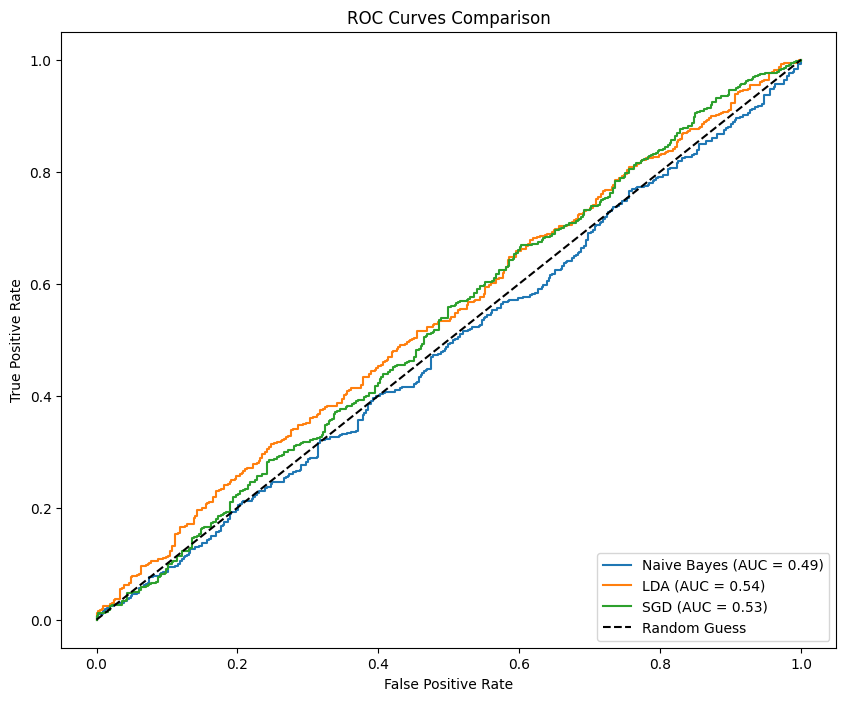

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))


def plot_roc(model, X_test, y_test, label):
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
    except AttributeError:
        y_prob = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.2f})")


plot_roc(pipeline_mnb, X_test, y_test, "Naive Bayes")
plot_roc(pipeline_lda, X_test, y_test, "LDA")
plot_roc(pipeline_sgd, X_test, y_test, "SGD")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend(loc="lower right")
plt.show()

Again, our LDA is performing the best but still not great. Naive Bayes is worse than random guessing. SGD is slightly better than random guessing but still not good. Overall, our models are struggling to distinguish between the classes effectively, as indicated by their ROC curves and AUC values.

Ultimately they are not performing well, because if they had just guessed 1 every time (assuming the market is always on an upward trend which is generally true), they would have done better. So we need to rethink our approach.